In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


Descarga de datos
--------

Los datos fueron tomados del portal de datos abiertos de Colombia.

Los datos que se van a analizar en este documento, Llegadas, Nacimientos, Salidas, Liquidaciones, Cancelaciones y Renovaciones de Empresas en Sabaneta.

Llegadas, Nacimientos, Salidas, Liquidaciones, Cancelaciones y Renovaciones de Empresas en Sabaneta
----
Conozca datos de llegadas, nacimientos, salidas, liquidaciones, cancelaciones y renovaciones de empresas en los diferentes sectores económicos del municipio de Sabaneta

### Información de la Entidad

| Campo | Detalle |
| :--- | :--- |
| **Departamento** | Antioquia |
| **Municipio** | Sabaneta |
| **Nombre de la Entidad** | Alcaldía de Sabaneta |
| **Orden** | Territorial |
| **Área o dependencia** | Secretaría de Planeación y Desarrollo Territorial, Cámara de Comercio del Aburrá Sur |
| **Sector** | Comercio, Industria y Turismo |

### Información de Datos

| Campo | Detalle |
| :--- | :--- |
| **Cobertura Geográfica** | Municipal |
| **Idioma** | Español |
| **Frecuencia de Actualización** | Anual |

| Nombre de la columna | Descripción | Nombre del campo API | Tipo de Dato |
| :--- | :--- | :--- | :--- |
| **Año** | | `a_o` | Número |
| **Cantidad** | Cantidad de empresas para el estado y año en particular | `cantidad` | Número |
| **Sector Económico** | Sector al que pertenecen las empresas para el estado y año en particular | `sector_econ_mico` | Texto |
| **Estados empresas** | Indica si las empresas son canceladas, liquidadas, sociedades constituidas, renovadas, o si se trata de un cambio de domicilio (bien sea entrante o saliente) | `estados_empresas_1` | Texto |
| **Cantidad de empleos** | | `cantidad_de_empleos` | Número |
| **Activos (Miles)** | | `activos_miles` | Número |

In [161]:
path = 'Llegadas,_Nacimientos,_Salidas,_Liquidaciones,_Cancelaciones_y_Renovaciones_de_Empresas_en_Sabaneta_20260127.csv'

df = pd.read_csv(path, thousands= '.', decimal= ',')

df

,Año,Cantidad,Sector Económico,Estados empresas,Cantidad de empleos,Activos (Miles)
0,2002,0,Agropecuarias,"Cambio de Domicilio, empresas que se fueron de...",248,16847200
1,2002,0,Minas y canteras,"Cambio de Domicilio, empresas que se fueron de...",248,16847200
2,2002,2,Manufactureras,"Cambio de Domicilio, empresas que se fueron de...",248,16847200
3,2002,0,"Electricidad, Gas y vapor","Cambio de Domicilio, empresas que se fueron de...",248,16847200
4,2002,1,Construcción,"Cambio de Domicilio, empresas que se fueron de...",248,16847200
...,...,...,...,...,...,...
1003,2020,0,"Electricidad, Gas y vapor",Sociedades Constituidas,0,185282161
1004,2020,40,Construcción,Sociedades Constituidas,123,185282161
1005,2020,39,"Transporte, Comunicaciones",Sociedades Constituidas,49,185282161
1006,2020,31,Seguros y Finanzas,Sociedades Constituidas,24,185282161


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Año                  1008 non-null   int64 
 1   Cantidad             1008 non-null   int64 
 2   Sector Económico     1008 non-null   object
 3   Estados empresas     1008 non-null   object
 4   Cantidad de empleos  1008 non-null   int64 
 5   Activos (Miles)      1008 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.4+ KB


In [163]:
df['Sector Económico'].unique()

array(['Agropecuarias', 'Minas y canteras', 'Manufactureras',
       'Electricidad, Gas y vapor', 'Construcción', 'Comercio',
       'Transporte, Comunicaciones', 'Seguros y Finanzas', 'Servicios'],
      dtype=object)

In [164]:
df['Estados empresas'].unique()

array(['Cambio de Domicilio, empresas que se fueron de Sabaneta',
       'Empresas Canceladas (Personas Naturales y Establecimientos de Comercio)',
       'Sociedades Renovadas', 'Sociedades Constituidas',
       'Cambio de Domicilio, empresas que llegan a Sabaneta',
       'Empresas Liquidadas (Sociedades)'], dtype=object)

Cantidades por año
---------

In [165]:
df_agrupado = df.groupby(['Año','Sector Económico', 'Estados empresas'])['Cantidad'].sum().reset_index()
df_agrupado

,Año,Sector Económico,Estados empresas,Cantidad
0,2002,Agropecuarias,"Cambio de Domicilio, empresas que llegan a Sab...",0
1,2002,Agropecuarias,"Cambio de Domicilio, empresas que se fueron de...",0
2,2002,Agropecuarias,Empresas Canceladas (Personas Naturales y Esta...,7
3,2002,Agropecuarias,Empresas Liquidadas (Sociedades),2
4,2002,Agropecuarias,Sociedades Constituidas,0
...,...,...,...,...
1003,2020,"Transporte, Comunicaciones","Cambio de Domicilio, empresas que se fueron de...",0
1004,2020,"Transporte, Comunicaciones",Empresas Canceladas (Personas Naturales y Esta...,31
1005,2020,"Transporte, Comunicaciones",Empresas Liquidadas (Sociedades),2
1006,2020,"Transporte, Comunicaciones",Sociedades Constituidas,39


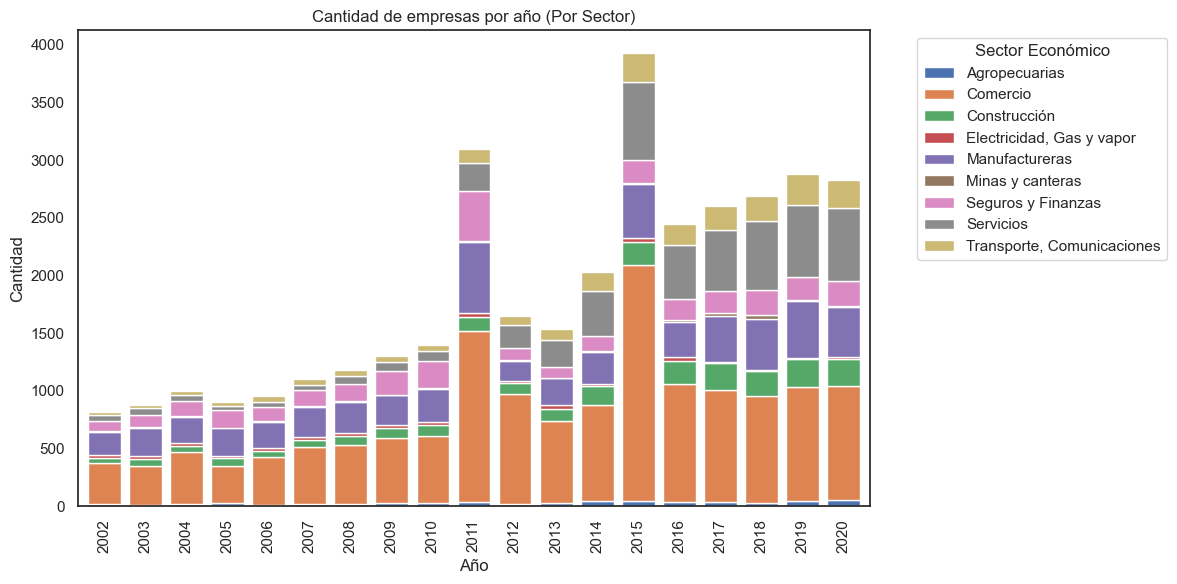

In [166]:
df_pivot = df_agrupado.pivot_table(
    index='Año', 
    columns='Sector Económico', 
    values='Cantidad', 
    aggfunc='sum'
).fillna(0)


df_pivot.plot(
    kind='bar', 
    stacked=True, # agrupar las barras
    figsize=(12, 6),
    width=0.8 
)

plt.title('Cantidad de empresas por año (Por Sector)')
plt.ylabel('Cantidad')
plt.xticks(rotation=90) 
plt.legend(title='Sector Económico', bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda afuera si tapa el gráfico
plt.tight_layout() 
plt.show()

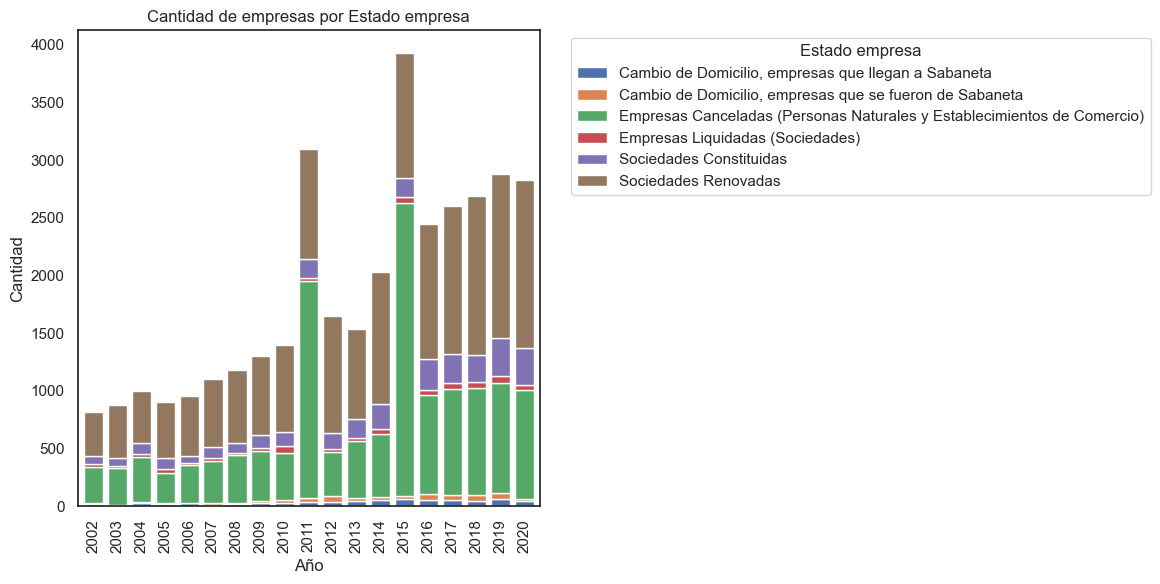

In [167]:
df_pivot_estado = df.pivot_table(
    index= 'Año',
    columns= 'Estados empresas',
    values= 'Cantidad',
    aggfunc= 'sum'
 ).fillna(0)

df_pivot_estado.plot(
    kind= 'bar',
    stacked= True,
    figsize= (12,6),
    width= 0.8
)

plt.title('Cantidad de empresas por Estado empresa')
plt.ylabel('Cantidad')
plt.xticks(rotation= 90)
plt.legend(title= 'Estado empresa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Analisis de natalidad y mortalidad empresarial
-------------------------------

In [168]:
sectores = list(df['Sector Económico'].unique())
sectores

['Agropecuarias',
 'Minas y canteras',
 'Manufactureras',
 'Electricidad, Gas y vapor',
 'Construcción',
 'Comercio',
 'Transporte, Comunicaciones',
 'Seguros y Finanzas',
 'Servicios']

In [169]:
df['Estados empresas'].unique()

array(['Cambio de Domicilio, empresas que se fueron de Sabaneta',
       'Empresas Canceladas (Personas Naturales y Establecimientos de Comercio)',
       'Sociedades Renovadas', 'Sociedades Constituidas',
       'Cambio de Domicilio, empresas que llegan a Sabaneta',
       'Empresas Liquidadas (Sociedades)'], dtype=object)

In [170]:
def clasificar(estado):
        if estado == 'Sociedades Constituidas':
            return 'Constituidas'
        elif estado in ['Empresas Liquidadas (Sociedades)',
                        'Empresas Canceladas (Personas Naturales y Establecimientos de Comercio)']:
            return 'Liquidadas/Canceladas'
        else:
            return 'Otro'

In [171]:
df_tasa_mortalidad = df[df['Estados empresas'].isin(['Sociedades Constituidas',
                                                    'Empresas Liquidadas (Sociedades)',
                                                    'Empresas Canceladas (Personas Naturales y Establecimientos de Comercio)'])].copy()


df_tasa_mortalidad['Categoria'] = df_tasa_mortalidad['Estados empresas'].apply(clasificar)

In [172]:
df_tasa_mortalidad_ = df_tasa_mortalidad.groupby(['Año', 'Categoria'])['Cantidad'].sum().reset_index()
df_tasa_mortalidad_

,Año,Categoria,Cantidad
0,2002,Constituidas,70
1,2002,Liquidadas/Canceladas,341
2,2003,Constituidas,67
3,2003,Liquidadas/Canceladas,337
4,2004,Constituidas,89
5,2004,Liquidadas/Canceladas,416
6,2005,Constituidas,94
7,2005,Liquidadas/Canceladas,288
8,2006,Constituidas,65
9,2006,Liquidadas/Canceladas,344


In [173]:
df_tasa_mortalidad_ = df_tasa_mortalidad_.pivot_table(
    index = 'Año',  
    columns = 'Categoria',                
    values = 'Cantidad',
    aggfunc = 'sum',                     
    fill_value = 0                        
)

df_tasa_mortalidad_ = df_tasa_mortalidad_.reset_index()

In [180]:
df_tasa_mortalidad_['Constituidas/(Liquidadas/Canceladas)'] = df_tasa_mortalidad_['Constituidas'] / df_tasa_mortalidad_['Liquidadas/Canceladas']
df_tasa_mortalidad_

Categoria,Año,Constituidas,Liquidadas/Canceladas,Constituidas/(Liquidadas/Canceladas)
0,2002,70,341,0.205279
1,2003,67,337,0.198813
2,2004,89,416,0.213942
3,2005,94,288,0.326389
4,2006,65,344,0.188953
5,2007,97,384,0.252604
6,2008,87,440,0.197727
7,2009,115,459,0.250545
8,2010,129,462,0.279221
9,2011,158,1906,0.082896


In [184]:
fig = px.line(
    df_tasa_mortalidad_, 
    x= 'Año',
    y= 'Constituidas/(Liquidadas/Canceladas)',
    title = 'Tasa de mortalidad anual',
    markers=True  
)

fig.show()

"El comportamiento atípico observado en la tasa de mortalidad empresarial durante el periodo 2011-2012
se atribuye a la implementación de la Ley 1429 de 2010 (Ley de Formalización y Generación de Empleo).
Específicamente, su Artículo 50 ordenó la depuración del Registro Mercantil, obligando a las Cámaras de
Comercio a cancelar automáticamente las matrículas de empresas que no hubieran renovado su registro 
en los últimos cinco años, lo que generó un incremento artificial en las cifras de cancelaciones."

---------------------
---------------------

"La contracción observada en los sectores de comercio e importaciones durante 2015 coincide con 
el choque macroeconómico nacional derivado de la caída de los precios del petróleo.
Según el Banco de la República, este fenómeno provocó una devaluación acelerada del peso colombiano 
(pasando de aprox. 2.000 a 3.000 COP), lo que incrementó los costos operativos para las empresas dependientes 
de insumos importados y afectó la dinámica de creación de nuevas sociedades comerciales."

Google (2026). Gemini. (versión Pro) [Modelo de la IA], URL (https://gemini.google.com/)

In [175]:
df_tasa_mortalidad_sector = df_tasa_mortalidad.groupby(['Año', 'Sector Económico', 'Categoria'])['Cantidad'].sum().reset_index()
df_tasa_mortalidad_sector

,Año,Sector Económico,Categoria,Cantidad
0,2002,Agropecuarias,Constituidas,0
1,2002,Agropecuarias,Liquidadas/Canceladas,9
2,2002,Comercio,Constituidas,29
3,2002,Comercio,Liquidadas/Canceladas,228
4,2002,Construcción,Constituidas,3
...,...,...,...,...
337,2020,Seguros y Finanzas,Liquidadas/Canceladas,32
338,2020,Servicios,Constituidas,72
339,2020,Servicios,Liquidadas/Canceladas,233
340,2020,"Transporte, Comunicaciones",Constituidas,39


In [176]:
df_tasa_mortalidad_sector = df_tasa_mortalidad_sector.pivot_table(
    index = ['Año', 'Sector Económico'],  
    columns = 'Categoria',                
    values = 'Cantidad',
    aggfunc = 'sum',                     
    fill_value = 0                        
)

df_tasa_mortalidad_sector = df_tasa_mortalidad_sector.reset_index()

In [177]:
df_tasa_mortalidad_sector['Constituidas/(Liquidadas/Canceladas)'] = df_tasa_mortalidad_sector['Constituidas'] / df_tasa_mortalidad_sector['Liquidadas/Canceladas']
df_tasa_mortalidad_sector

Categoria,Año,Sector Económico,Constituidas,Liquidadas/Canceladas,Constituidas/(Liquidadas/Canceladas)
0,2002,Agropecuarias,0,9,0.000000
1,2002,Comercio,29,228,0.127193
2,2002,Construcción,3,5,0.600000
3,2002,"Electricidad, Gas y vapor",18,2,9.000000
4,2002,Manufactureras,0,59,0.000000
...,...,...,...,...,...
166,2020,Manufactureras,40,96,0.416667
167,2020,Minas y canteras,1,1,1.000000
168,2020,Seguros y Finanzas,31,32,0.968750
169,2020,Servicios,72,233,0.309013


In [186]:
fig = px.line(
    df_tasa_mortalidad_sector, 
    x= 'Año',
    y= 'Constituidas/(Liquidadas/Canceladas)',
    color= 'Sector Económico',
    title = 'Tasa de mortalidad anual',
    markers=True  
)

fig.show()

In [178]:


color_map = {
    'Constituidas': 'darkblue',
    'Liquidadas/Canceladas': 'orange'
}

for sector in sectores:
    
    df_sector = df[df['Sector Económico'] == sector].copy()
   
    df_sector['Categoria'] = df_sector['Estados empresas'].apply(clasificar)
    
    df_plot = df_sector[df_sector['Categoria'].isin(['Constituidas', 'Liquidadas/Canceladas'])]
    
    df_plot = df_plot.groupby(['Año', 'Categoria'])['Cantidad'].sum().reset_index()

    fig = px.bar(
        df_plot,
        x= 'Año',
        y= 'Cantidad',
        color= 'Categoria',         # Aquí ocurre la magia: separa por colores solo
        color_discrete_map=color_map, # Usamos tus colores
        title= f'Sector Económico: {sector}',
        opacity= 0.5,               
        barmode= 'group'          # Poner las barras una al lado de la otra

    )

    fig.update_layout(
        xaxis_type= 'category', # Para que muestre todos los años
        template= 'plotly_white' #tema
    )
    
    fig.show()

Tiene algun beneficio registrar una empresa en una ciudad especifica ??

Influyen los cambios de administraciones ??

Informacion Economica

Preguntas a la IA 

Por que registrar mi empresa en Sabaneta ??

Como miden el empleo ??